# Renewable Energy Consumption — Exploratory Data Analysis

#### Objective:

 Analyze global renewable energy consumption patterns across countries and over time, identify major differences and trends, and prepare reliable country-level data for integration into the Global Climate & Sustainability Dashboard.

 

#### Dataset

- Source: World Bank — World Development Indicators
- Indicator: EG.FEC.RNEW.ZS
- Measure: Renewable energy consumption (% of total final energy consumption)
- Source organization: International Energy Agency (IEA)

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
import sys
import os

# Add project root (two levels up from notebooks/eda)
project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
sys.path.append(project_root)

from src.api.Renew_eng_consumption import renew_eng_consum

### Data Source and Metadat

In [ ]:
data , metadata = renew_eng_consum( )

# saving raw values
data.to_csv('../../data/raw/Renewable_eng_raw.csv' , index = False)
print('\nRaw data saved succesfully')

Processing request...
Fetching page 9/9...
Done. Collected 17490 records .
converting into DataFrame
Got dataFrame shape : (17490, 4)

Raw data saved succesfully


In [ ]:
metadata

{'id': 'EG.FEC.RNEW.ZS',
 'name': 'Renewable energy consumption (% of total final energy consumption)',
 'unit': '',
 'source': {'id': '2', 'value': 'World Development Indicators'},
 'sourceNote': 'Renewable energy consumption is the share of renewable energy in total final energy consumption.',
 'sourceOrganization': 'IEA Energy Statistics Data Browser, International Energy Agency (IEA), uri: https://www.iea.org/data-and-statistics/data-tools/energy-statistics-data-browser, publisher: International Energy Agency (IEA), date accessed: 2025-03-25',
 'topics': [{'id': '5', 'value': 'Energy & Mining '},
  {'id': '19', 'value': 'Climate Change'},
  {'id': '6', 'value': 'Environment '}]}

### Data Acquisition

In [ ]:
df = pd.read_csv('../../data/raw/Renewable_eng_raw.csv')
print('data load successfully') 

data load successfully


### Data understanding

In [ ]:
df = df.sort_values('year')
display('dataFrame head :',df.head())
display('dataFrame tail :',df.tail())

'dataFrame head :'

,year,total_renewable_energy(%),Country_code,country
2705,1960,NaN,SST,Small states
10295,1960,NaN,KGZ,Kyrgyz Republic
14783,1960,NaN,SLB,Solomon Islands
4685,1960,NaN,BTN,Bhutan
7655,1960,NaN,FIN,Finland


'dataFrame tail :'

,year,total_renewable_energy(%),Country_code,country
11154,2025,NaN,MDV,Maldives
10758,2025,NaN,LTU,Lithuania
16830,2025,NaN,URY,Uruguay
0,2025,NaN,AFE,Africa Eastern and Southern
10890,2025,NaN,MAC,"Macao SAR, China"


In [ ]:
df.info()

<class 'pandas.DataFrame'>
Index: 17490 entries, 2705 to 10890
Data columns (total 4 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   year                       17490 non-null  int64  
 1   total_renewable_energy(%)  8203 non-null   float64
 2   Country_code               17160 non-null  str    
 3   country                    17490 non-null  str    
dtypes: float64(1), int64(1), str(2)
memory usage: 683.2 KB


In [ ]:
print(f"dataFrame has '{df.shape[0]}' rows")
columns = df.columns.to_list()
print(f'There are total {len(columns)} columns in dataFrame : ' , columns)

dataFrame has '17490' rows
There are total 4 columns in dataFrame :  ['year', 'total_renewable_energy(%)', 'Country_code', 'country']


In [ ]:
print('Data statistical summary :')
display(df.describe())
print('\nstatistical summary for string type columns :')
df.describe(include = str)

Data statistical summary :


,year,total_renewable_energy(%)
count,17490.000000,8203.000000
mean,1992.500000,31.255279
std,19.050916,29.655599
min,1960.000000,0.000000
25%,1976.000000,5.900000
50%,1992.500000,21.200000
75%,2009.000000,54.000000
max,2025.000000,98.300000



statistical summary for string type columns :


,Country_code,country
count,17160,17490
unique,260,265
top,SST,Small states
freq,66,66


### Data Quality check

##### missing value

In [ ]:
missing = (
    df.isna()
      .sum()
      .to_frame('missing_count')
)

missing['missing_%'] = (
    np.round(missing['missing_count'] / len(df) * 100 , 2)
)

display(missing)
print('Total null values are ',df.isna().sum().sum()) 


,missing_count,missing_%
year,0,0.00
total_renewable_energy(%),9287,53.10
Country_code,330,1.89
country,0,0.00


Total null values are  9617


##### Checking for 0 values

In [ ]:
print('Count of 0 in each columns are :')
print(df.eq(0).sum())
print('\nTotal zero values are ', df.eq(0).sum().sum())

Count of 0 in each columns are :
year                           0
total_renewable_energy(%)    410
Country_code                   0
country                        0
dtype: int64

Total zero values are  410


In [ ]:
print(f'Dataset year range from {df.year.min()} to {df.year.max()}')

# Zero data seummary
zero_summary = (df[df['total_renewable_energy(%)']==0].
                groupby('Country_code')
                .agg(
                    First_zero_year = ('year','min'),
                    last_zero_year = ('year','max'),
                    zero_count = ('year' , 'count')
                ).sort_values('zero_count').reset_index()
                )
print('Zero data summary')
zero_summary


Dataset year range from 1960 to 2025
Zero data summary


,Country_code,First_zero_year,last_zero_year,zero_count
0,HKG,2000,2000,1
1,ARE,1990,1991,2
2,CUW,1990,1992,3
3,KNA,2006,2009,4
4,BMU,1990,1994,5
5,TKM,1990,2012,9
6,SXM,2012,2022,11
7,BHS,1990,2000,11
8,MLT,1990,2001,12
9,QAT,1993,2021,12


##### Handling 0 values

Since API return missing/null value as none not as 0 . here 0 is accutal % . so zero can not be drop/ remove .

#### Duplicates & unique

In [ ]:

print('total duplicate values',df.duplicated().sum())
print('\ntotal unique values are :')
print(df.nunique())



total duplicate values 0

total unique values are :
year                           66
total_renewable_energy(%)    2357
Country_code                  260
country                       265
dtype: int64


### Data Cleaning

Country codes are required for geographical visualization and mapping.
Therefore, observations without a country code are removed.

Missing values in the renewable-energy indicator are also removed
because they do not contain an observed measurement.

In [ ]:
before = len(df)
print('Null value Before droping nan values   :' , df.isna().sum().sum())
df = df.dropna(subset = ['total_renewable_energy(%)','Country_code'])
print('Null value after droping nan values    :' , df.isna().sum().sum())

df= df.drop_duplicates()
print('Total duplicat values after droping is :' ,df.duplicated().sum() )

Null value Before droping nan values   : 0
Null value after droping nan values    : 0
total duplicat values after droping is : 0


#### Data-retention summary

In [ ]:
after = len(df)

print("Rows before cleaning:", before)
print("Rows after cleaning:", after)
print("Rows removed:", before - after)
print("Retention rate:", f"{after / before:.2%}")

Rows before cleaning: 17490
Rows after cleaning: 8079
Rows removed: 9411
Retention rate: 46.19%


#### aggregate codes

In [ ]:
country_df = pd.read_csv('../../data/reference/country_classification.csv')
country_df
df = df.merge(country_df[['Country_code' , 'is_aggregate']] , on = 'Country_code' , how = 'left')
agg_df = df[df['is_aggregate']==True].copy()

# saving regional data into septarate file 
agg_df.to_csv('../../data/raw/regional_renewableEnery.csv') 

In [ ]:
# creating DataFrame with no aggregate country
f_df = df[df['is_aggregate'] == False].copy()
f_df = f_df.drop(columns = 'is_aggregate' )
f_df.head()

,year,total_renewable_energy(%),Country_code,country
0,1990,64.0,KIR,Kiribati
1,1990,57.1,FJI,Fiji
2,1990,76.5,KEN,Kenya
4,1990,22.1,PSE,West Bank and Gaza
6,1990,62.2,SWZ,Eswatini


### Univariate Analysis


#### Renewable energy Distribution and BoxPlot

Text(0.5, 1.0, 'boxplot ')

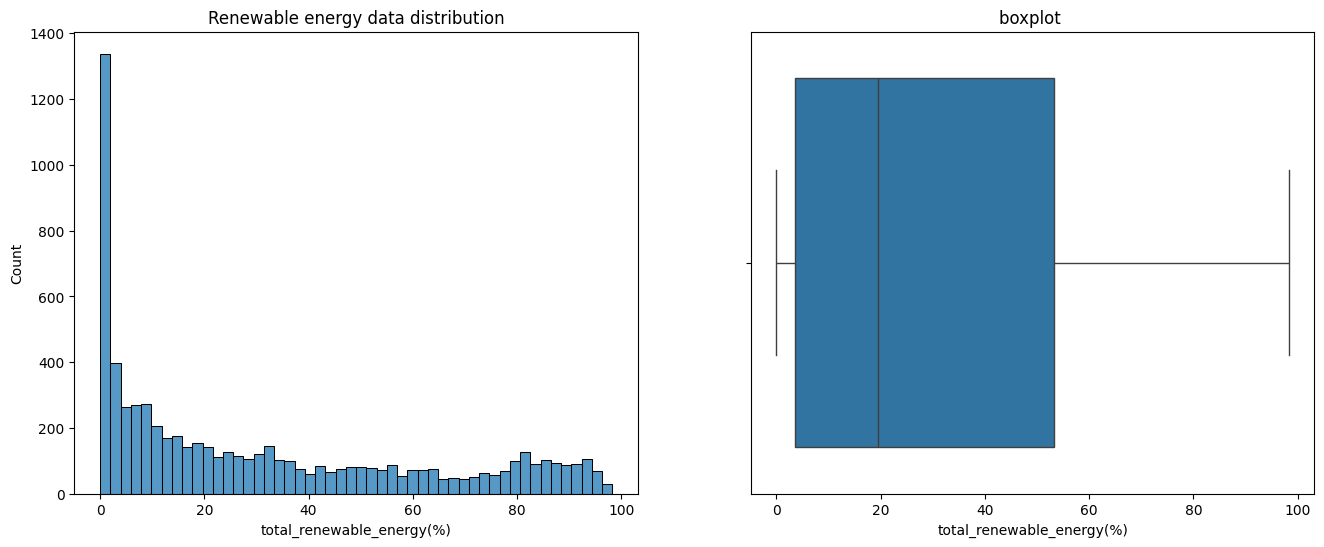

In [ ]:
plt.figure(figsize = (16,6))

plt.subplot(1,2,1)
sns.histplot(data =f_df , x='total_renewable_energy(%)' ,bins = 50)
plt.title('Renewable energy data distribution')


plt.subplot(1,2,2)
sns.boxplot(data= f_df , x= 'total_renewable_energy(%)')
plt.title('boxplot ')



##### Graph finding 
- Renewable energy hitogram show a right skew data with values concentrated near 0.
- At the same time box plot for renewable energy shows wide spread , meadian around 20% , no outliers .

#### Skewness and Kurtosis

In [ ]:
value = f_df['total_renewable_energy(%)']

print("Skewness:", np.round(value.skew(),3))
print("Kurtosis:", np.round(value.kurt(),3))

Skewness: 0.761
Kurtosis: -0.8


The distribution shows moderate positive skewness (skewness = 0.761), indicating a longer upper tail and greater concentration toward lower renewable-energy shares.

### Distribution Transformation

The renewable-energy variable contains a substantial number of zero
observations and is not normally distributed. `log1p(x)` is used to
compress larger values while preserving zero observations.

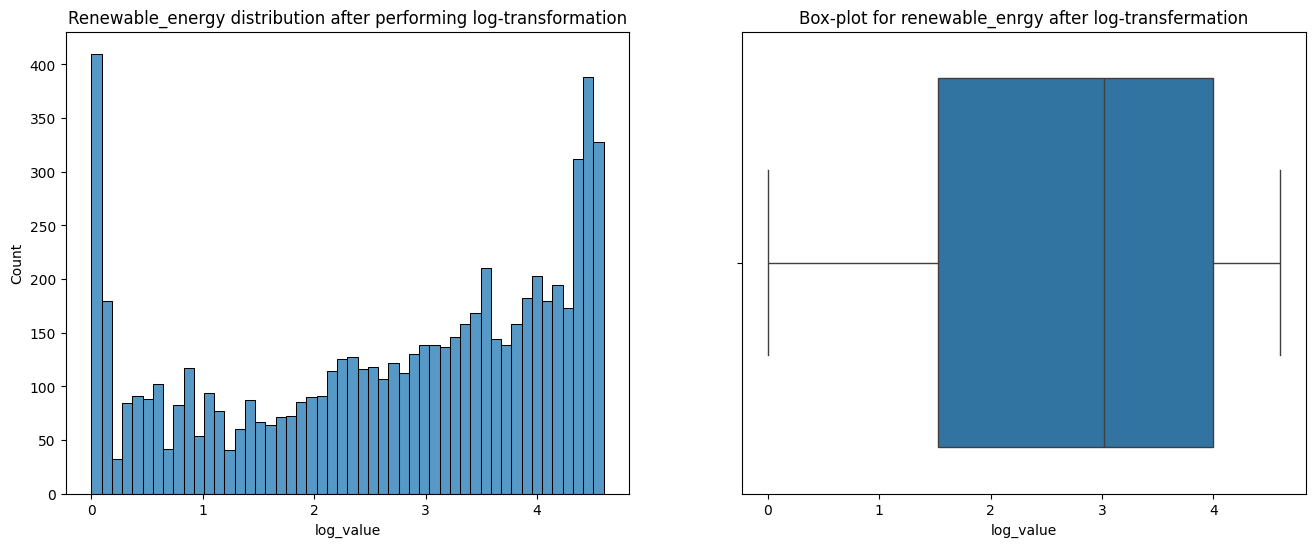

In [ ]:
f_df['log_value'] = np.log1p(df['total_renewable_energy(%)'])

plt.figure(figsize = (16,6))

plt.subplot(1,2,1)
sns.histplot(data = f_df , x= 'log_value' , bins = 50)
plt.title('Renewable_energy distribution after performing log-transformation')

plt.subplot(1,2,2)
sns.boxplot(data = f_df , x= 'log_value' )
plt.title('Box-plot for renewable_enrgy after log-transfermation')

plt.show()

#### graph finding
- boxplot median sits at roughly 3.0 on the log1p scale, which corresponds to about 19–21% on the original percentage scale (np.expm1(3) ≈ 19.1%) — consistent with the actual dataset median of 21.2% from describe().
- Boxplot : Log-transformed median ≈ 3.0, which corresponds to ~19–21% on the original scale — consistent with the dataset median

Skewness and kurtosis after log-transformation

In [ ]:
print("Original skewness:", np.round(f_df['total_renewable_energy(%)'].skew(),3))
print("Log skewness:", np.round(f_df['log_value'].skew(),3))

Original skewness: 0.761
Log skewness: -0.485


### Temporal Analysis

#### Yearly average renewable energy consumption over time

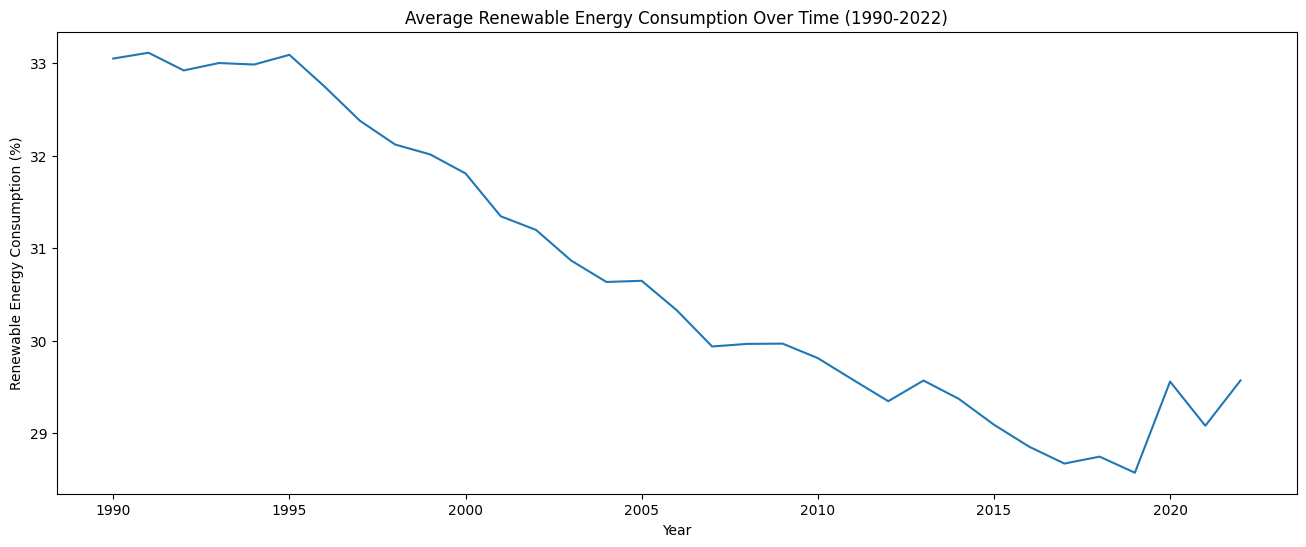

In [ ]:
yearly_avg = f_df.groupby('year')['total_renewable_energy(%)'].mean().reset_index()
yearly_avg

plt.figure(figsize =(16,6))
sns.lineplot(data = yearly_avg ,
             x= 'year',
             y= 'total_renewable_energy(%)')
plt.title(f'Average Renewable Energy Consumption Over Time ({f_df.year.min()}-{f_df.year.max()})')
plt.xlabel('Year')
plt.ylabel('Renewable Energy Consumption (%)')
plt.show()

##### Graph finding 
- In 1990-1995 renewable enery consumption was roughly aroung 33% with small variation .
- From 1995 to around 2017 there is drop in renewablel energy consumption .
 
 

#### Chagne-over-time in renewable energy consumption

Calculating top countries based on there last to latest year renewable energy consumption change .


In [ ]:
top_n = 5
f_df = f_df.sort_values(
    ['Country_code', 'year']
).copy()
country_change = (
    f_df.groupby(['Country_code', 'country'])
    .agg(
        first_year=('year', 'first'),
        latest_year=('year', 'last'),
        first_value=('total_renewable_energy(%)', 'first'),
        latest_value=('total_renewable_energy(%)', 'last'),
       
    )
    .reset_index()
)

country_change['total_change_pp'] = (
    country_change['latest_value'] -
    country_change['first_value']
)
top_countries = (
    country_change
    .nlargest(top_n, 'total_change_pp')['country']
    .tolist()
)
top_countries

['Estonia', 'Denmark', 'Lithuania', 'Bosnia and Herzegovina', 'Iceland']

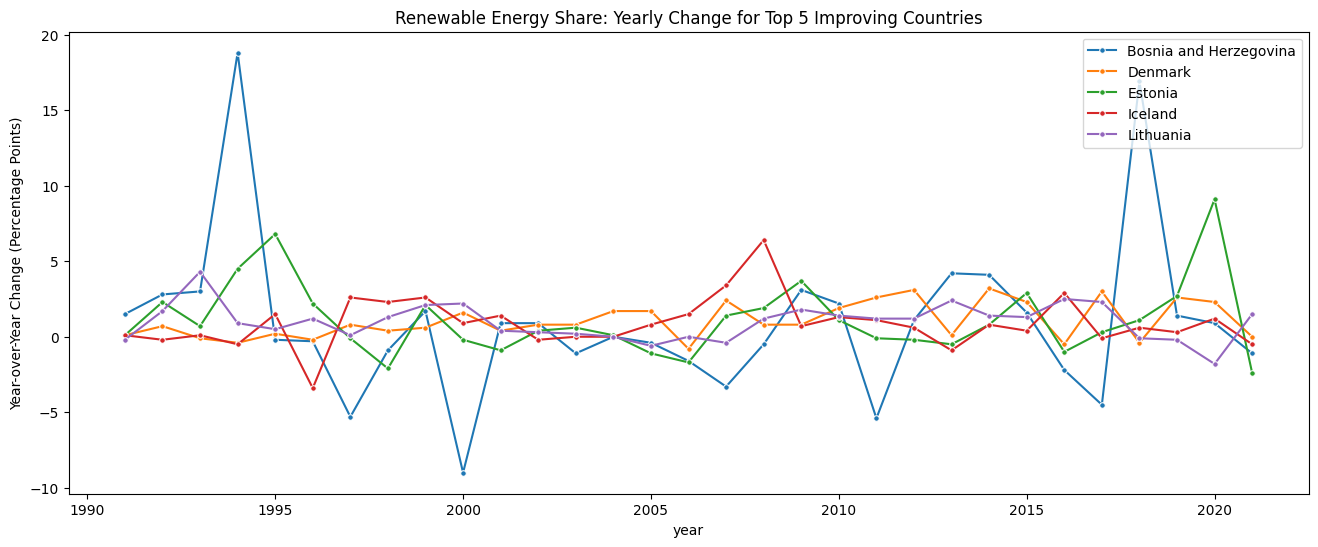

In [ ]:
plt.figure(figsize = (16,6))
f_df['yoy_change'] = f_df.groupby('Country_code')['total_renewable_energy(%)'].diff()
top10_yoy_df = f_df[f_df.country.isin(top_countries)]

sns.lineplot(data = top10_yoy_df , x= 'year' , y = 'yoy_change' , hue = 'country' , marker = 'o' , markersize = '4')
plt.title(f'Renewable Energy Share: Yearly Change for Top {top_n} Improving Countries')
plt.ylabel('Year-over-Year Change (Percentage Points)')
plt.xlabel('year') 
plt.legend(loc= 'upper right')
plt.show()
 
 

#### Graph finding
- All 4 country shows a yers-over-year change roughly aroung -5 to 5 , but 'Bosnia and Herzegovina' show a high volatily (-9 to 19) and many spikes .

### Country level Analysis

#### Top countries 20 by renuewable energy consumption

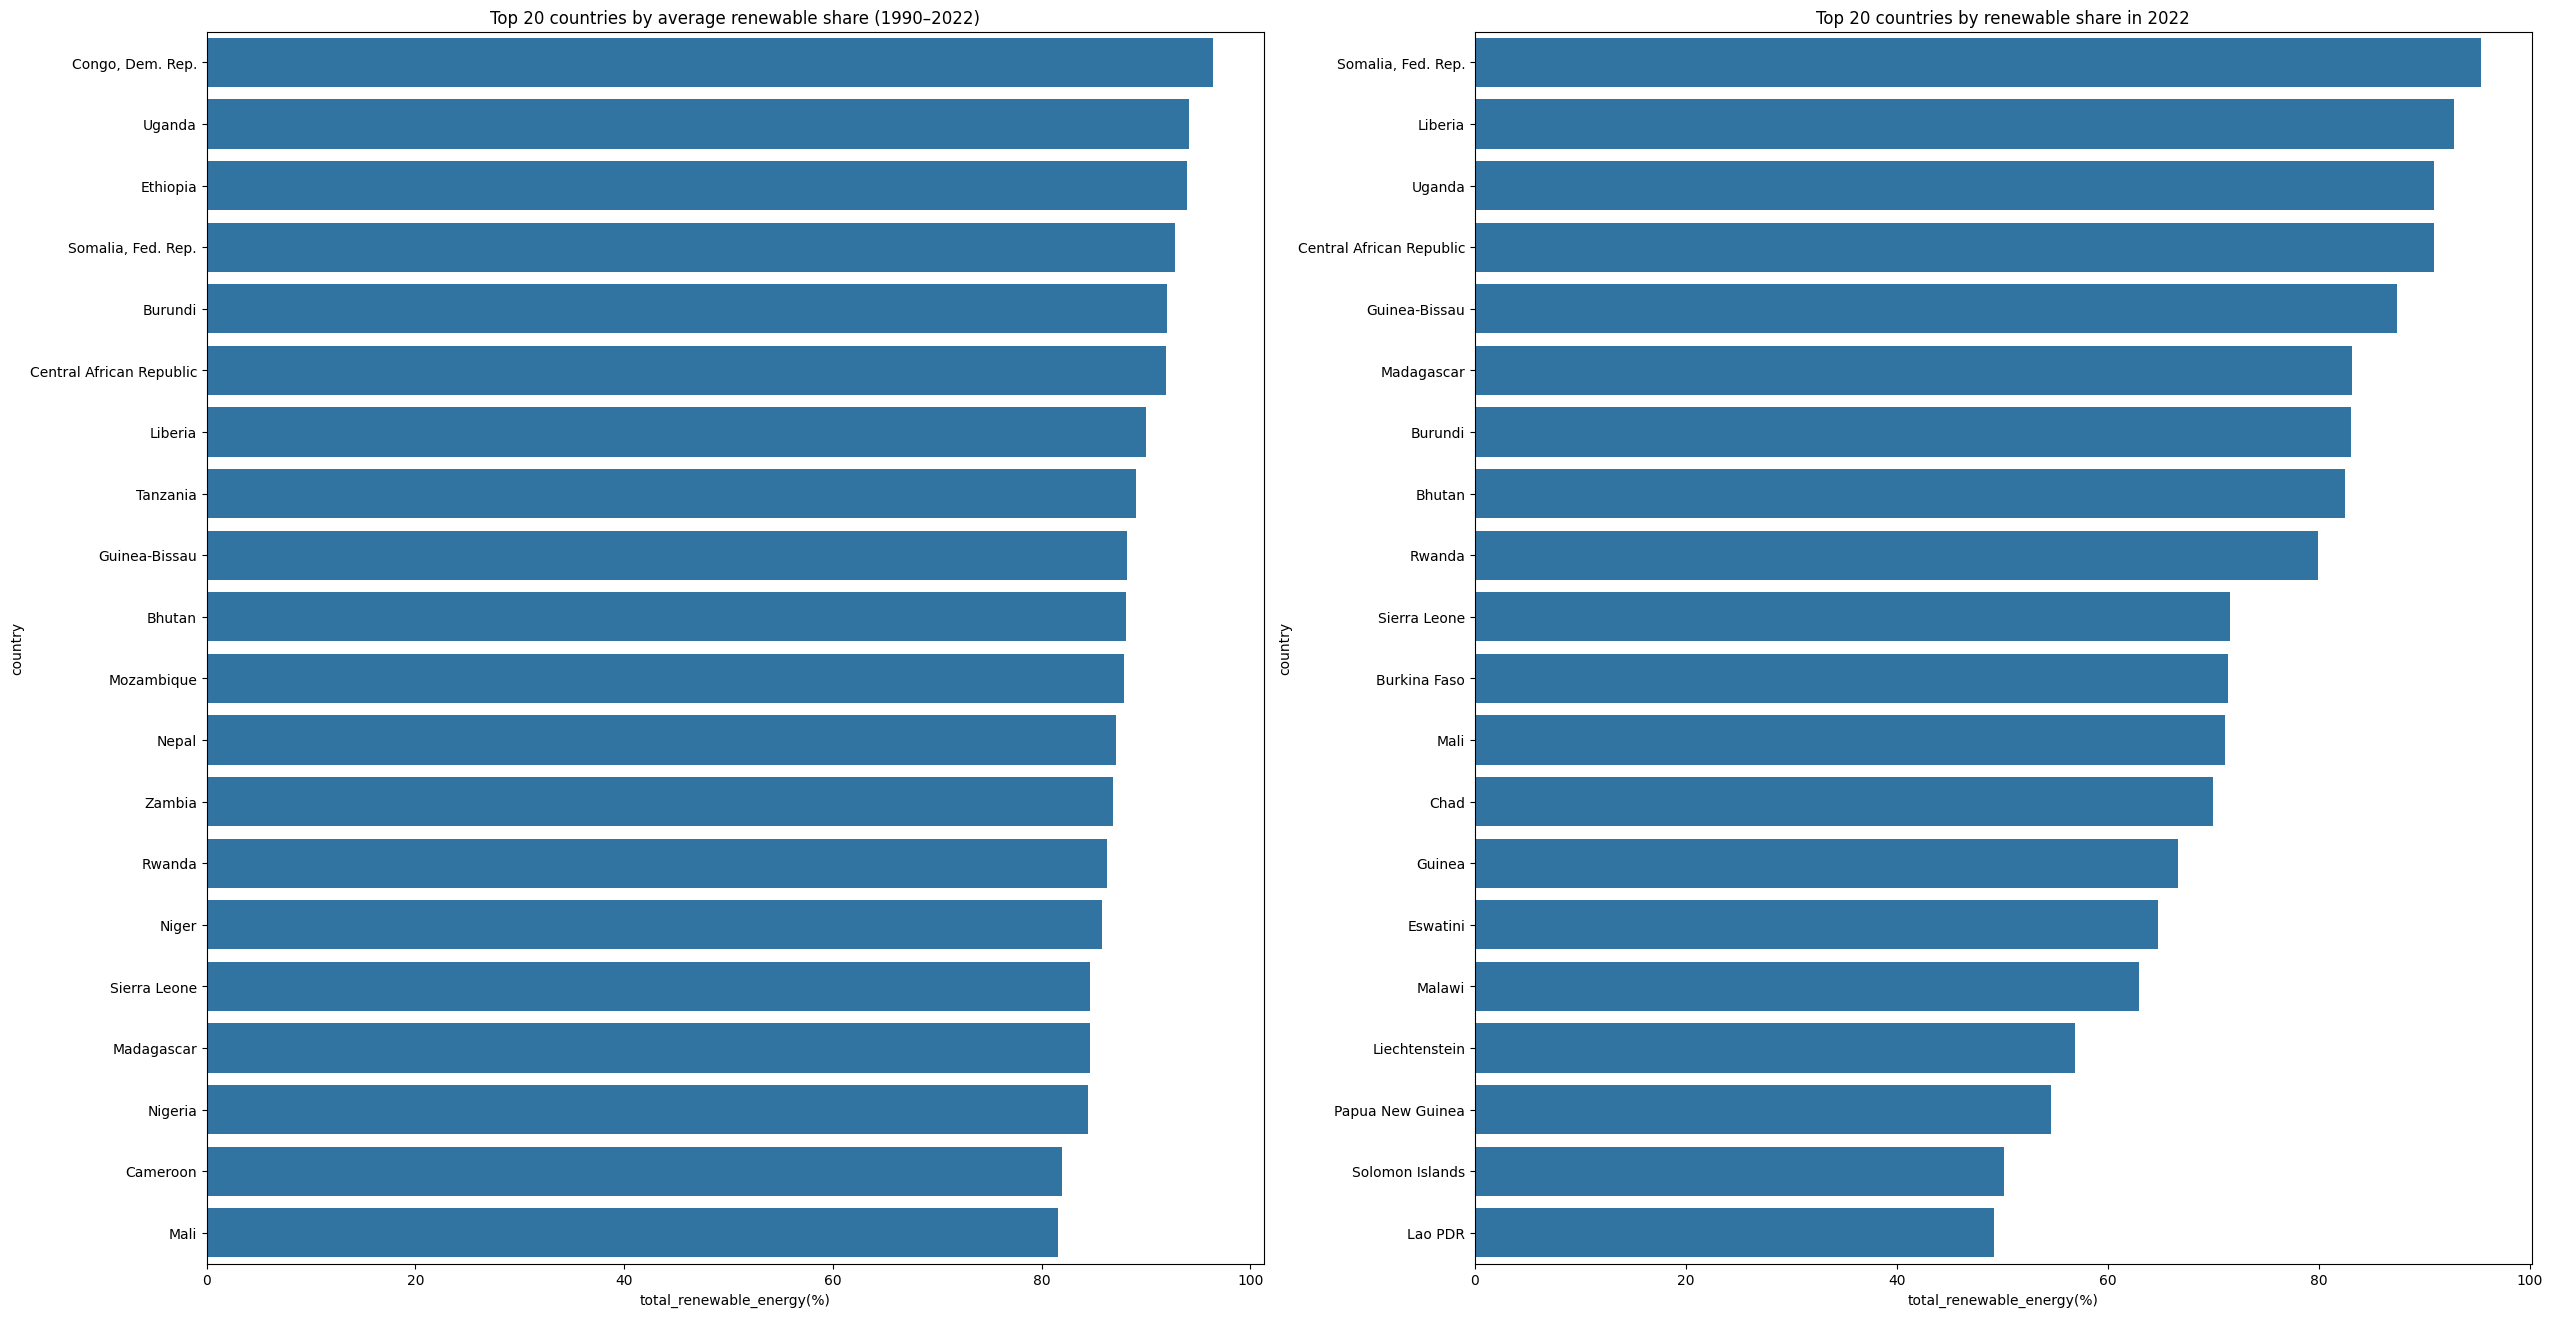

In [ ]:
plt.figure(figsize = (30,16))

plt.subplot(1,2,1)
top20_avg = f_df.groupby('country')['total_renewable_energy(%)'].mean().nlargest(20).to_frame().reset_index()
sns.barplot(data = top20_avg , x= 'total_renewable_energy(%)' ,y = 'country')
plt.title(f'Top 20 countries by average renewable share ({f_df.year.min()}–{f_df.year.max()})')

plt.subplot(1,2,2)
top20_p = (f_df[f_df['year']== f_df.year.max()]
           .sort_values('total_renewable_energy(%)', ascending= False)
           .head(20))
sns.barplot(data = top20_p , y= 'country' , x = 'total_renewable_energy(%)')
plt.title(f'Top 20 countries by renewable share in {f_df.year.max()}')

plt.show()


#### bottom countries 20 by renuewable energy consumption

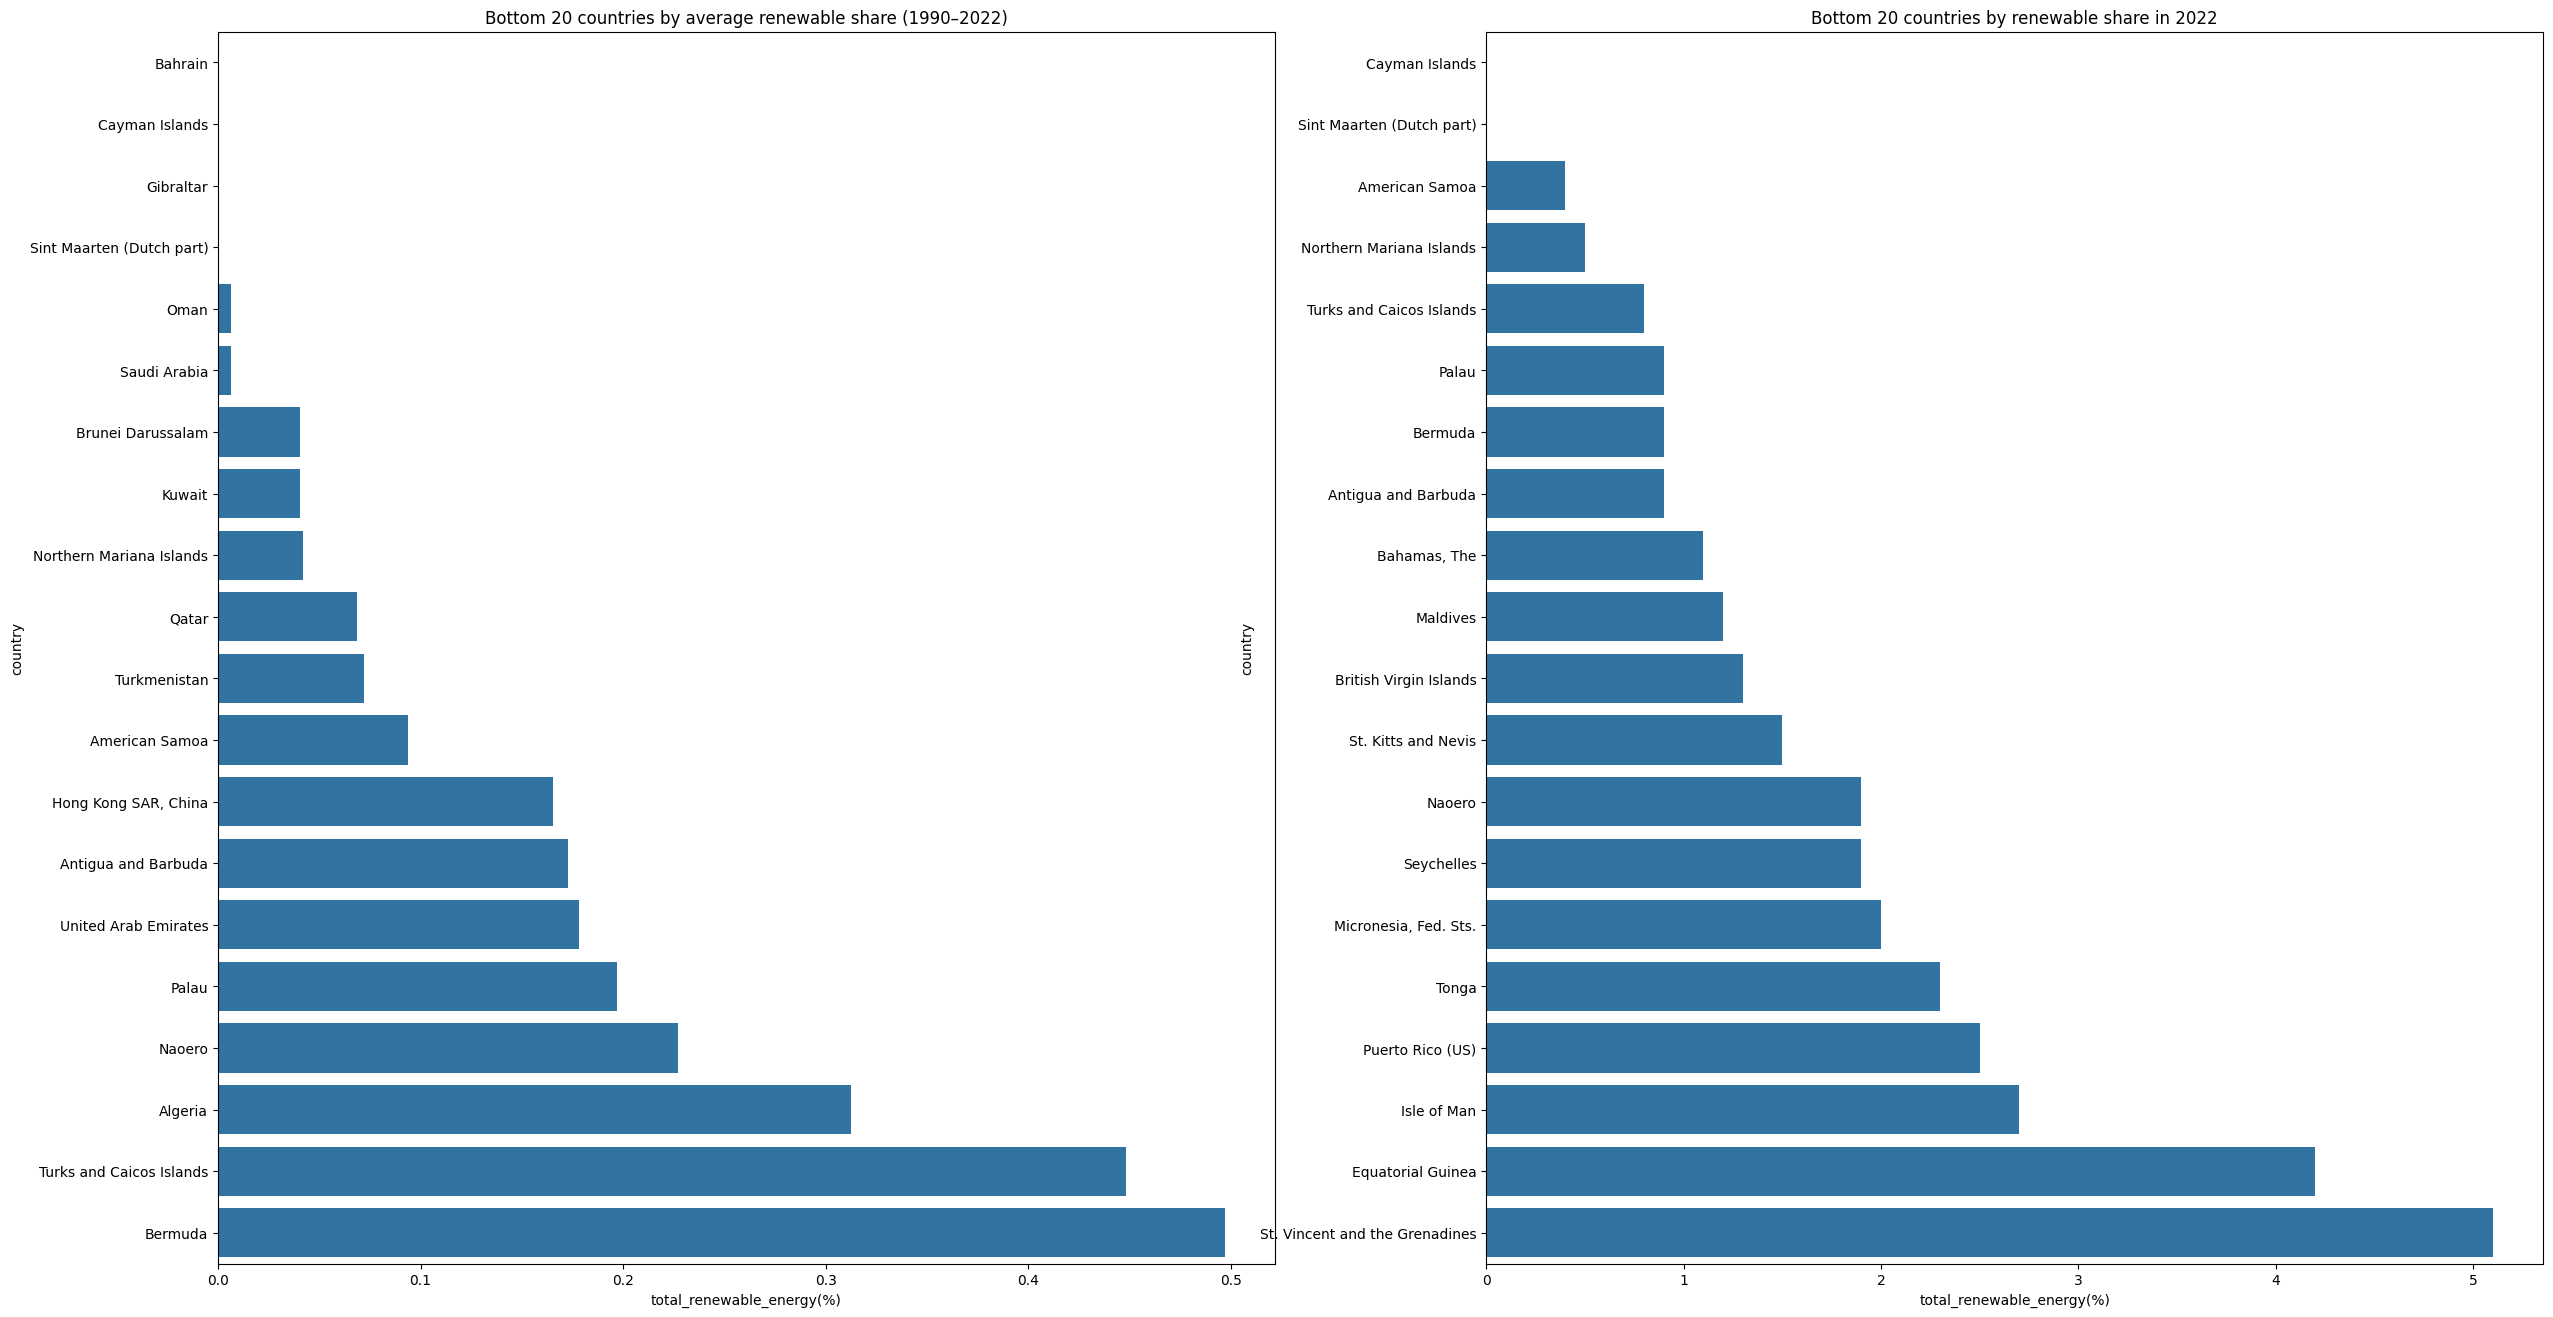

In [ ]:
plt.figure(figsize = (30,16))

plt.subplot(1,2,1)
bottom20_avg = f_df.groupby('country')['total_renewable_energy(%)'].mean().nsmallest(20).to_frame().reset_index()
sns.barplot(data = bottom20_avg , x= 'total_renewable_energy(%)' ,y = 'country')
plt.title(f"Bottom 20 countries by average renewable share ({f_df.year.min()}–{f_df.year.max()})")

plt.subplot(1,2,2)
bottom20_p = (f_df[f_df['year']== f_df.year.max()]
           .sort_values('total_renewable_energy(%)', ascending= True)
           .head(20))
sns.barplot(data = bottom20_p , y= 'country' , x = 'total_renewable_energy(%)')
plt.title(f'Bottom 20 countries by renewable share in {f_df.year.max()}')

plt.show()


### Top 5 overlall renewabel energy consuming countries trend

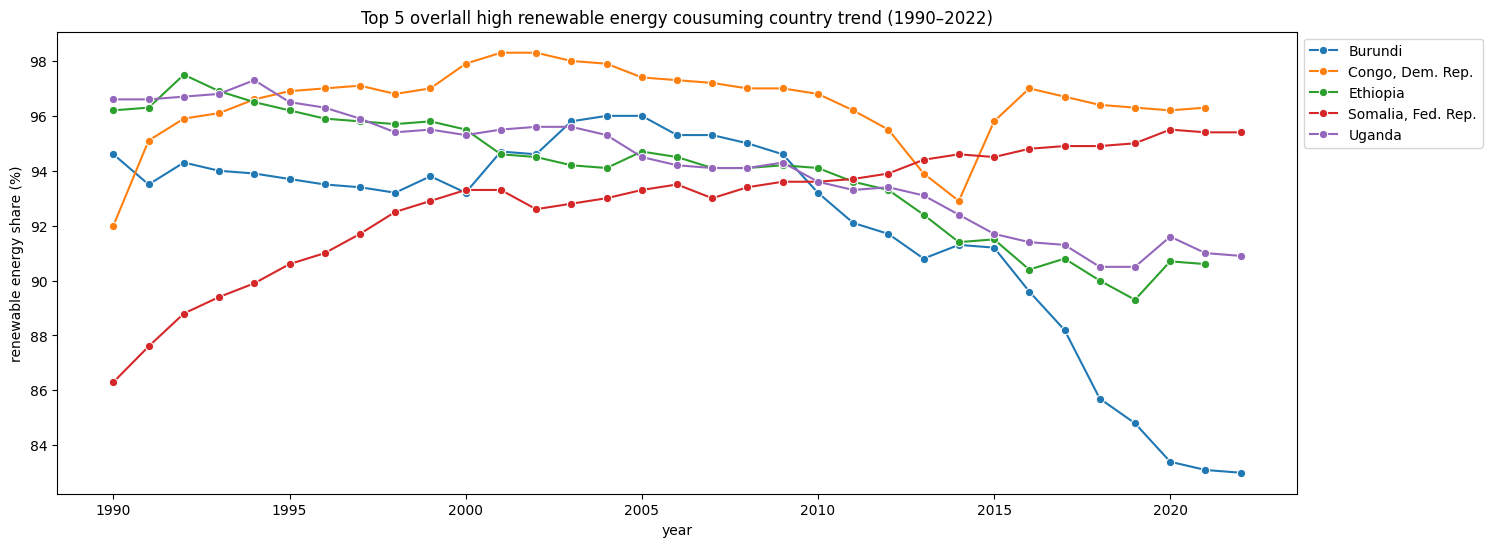

In [ ]:
top_n = 5
top10 = (f_df.groupby('country')['total_renewable_energy(%)']
         .mean()
         .nlargest(top_n)
         .index
         .tolist())
top10_df = f_df[f_df.country.isin(top10)] 
 
plt.figure(figsize = (16,6))
 
sns.lineplot(data=top10_df, x='year', y='total_renewable_energy(%)', hue='country' , marker = 'o')
plt.title(f'Top {top_n} overlall high renewable energy cousuming country trend ({f_df.year.min()}–{f_df.year.max()})')
plt.ylabel('renewable energy share (%)')
# plt.legend(loc='lower left')
plt.legend(bbox_to_anchor=(1, 1), loc='upper left')
plt.show()

### outlier investigation
Using IQR method

In [ ]:
Q1 = f_df['total_renewable_energy(%)'].quantile(0.25)
Q3 = f_df['total_renewable_energy(%)'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = f_df[
    (f_df['total_renewable_energy(%)'] < lower) |
    (f_df['total_renewable_energy(%)'] > upper)
]
print('total outlier',len(outliers))

invalid = df[
    (df['total_renewable_energy(%)'] < 0) |
    (df['total_renewable_energy(%)'] > 100)
]

print('total invalid data',len(invalid))


total outlier 0
total invalid data 0


No observations were identified as statistical outliers under the 1.5×IQR criterion. This does not imply that all extreme values are erroneous; extreme renewable-energy shares may represent genuine country-level differences.

# Key Findings

 
1. Significant missing-data limitation

53.1% of raw observations have missing renewable-energy values, making data coverage an important consideration when interpreting country and temporal comparisons.

2. Wide cross-country variation

Renewable-energy shares range from 0% to 98.3%, indicating substantial differences in the contribution of renewable energy to total final energy consumption.

3. Distribution is positively skewed

The renewable-energy share has moderate positive skewness (0.761), with the median at 21% compared with a mean of approximately 31.2%.

4. Zero values are valid observations

The dataset contains 410 observations with a 0% renewable-energy share. These were retained because zero represents an observed value rather than a missing-value code.

5. Country coverage varies

Country-level observation periods are not uniform, so first-to-latest comparisons should be interpreted alongside each country's actual observation period.

6. Renewable-energy share varies over time

The unweighted mean of available country-level observations changes across the 1990–2022 period, indicating variation in renewable-energy shares over time.

7. Countries show different rates of transition

First-to-latest percentage-point changes reveal substantial differences in how renewable-energy shares have changed across countries.

8. Dashboard implication

The cleaned country-level dataset supports country comparison, temporal trends, ranking, and geographical visualization in the Global Climate & Sustainability Dashboard.


### Final dataset for Dashboard

In [ ]:
f_df.to_csv('../../data/processed/renewable_energy_clean.csv' , index=False)